In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/kag_risk_factors_cervical_cancer.csv")
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.0,0.0,...,?,?,0,0,0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,1,0
856,33,2.0,24.0,2.0,0.0,0.0,0.0,1.0,0.08,0.0,...,?,?,0,0,0,0,0,0,0,0


In [11]:
df.shape

(858, 36)

In [6]:
# ============================================================
# PHASE 1: DATA INGESTION & EXPLORATION
# ============================================================
df = pd.read_csv("../data/kag_risk_factors_cervical_cancer.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nValue counts for targets:")
for target in ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']:
    print(f"\n{target}:\n", df[target].value_counts())

Shape: (858, 36)

Columns:
 ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

First 5 rows:
    Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.

In [7]:
# ============================================================
# PHASE 2: DATA PREPROCESSING
# ============================================================

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print("Missing values per column:\n", df.isnull().sum())

# Fill missing values with column median (robust to skew)
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing values after imputation:\n", df.isnull().sum().sum())
print("\nFinal shape:", df.shape)

Missing values per column:
 Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:H

In [8]:
# ============================================================
# PHASE 3: FEATURE & TARGET SETUP
# ============================================================

# All 4 targets
TARGETS = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

# Features: all columns except the 4 targets
FEATURES = [col for col in df.columns if col not in TARGETS]

print(f"Number of features: {len(FEATURES)}")
print(f"Features: {FEATURES}")

Number of features: 32
Features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [10]:
# ============================================================
# PHASE 4: MODEL TRAINING
# ============================================================

models = {}       # store trained models
splits = {}       # store train/test splits per target

for target in TARGETS:
    print(f"\n{'='*50}")
    print(f"Training Random Forest for target: {target}")
    print(f"{'='*50}")
    
    X = df[FEATURES]
    y = df[target]
    
    # Train-test split (80/20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Train basic Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_scaled, y_train)
    
    # Store
    models[target] = rf
    splits[target] = (X_train_scaled, X_test_scaled, y_train, y_test)
    
    print(f"  Training samples : {X_train.shape[0]}")
    print(f"  Test samples     : {X_test.shape[0]}")
    print(f"  Class distribution (train): {dict(y_train.value_counts())}")


Training Random Forest for target: Hinselmann
  Training samples : 686
  Test samples     : 172
  Class distribution (train): {0: np.int64(658), 1: np.int64(28)}

Training Random Forest for target: Schiller
  Training samples : 686
  Test samples     : 172
  Class distribution (train): {0: np.int64(627), 1: np.int64(59)}

Training Random Forest for target: Citology
  Training samples : 686
  Test samples     : 172
  Class distribution (train): {0: np.int64(651), 1: np.int64(35)}

Training Random Forest for target: Biopsy
  Training samples : 686
  Test samples     : 172
  Class distribution (train): {0: np.int64(642), 1: np.int64(44)}



EVALUATION — Target: Hinselmann

📋 Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.96      1.00      0.98       165
Positive (1)       0.00      0.00      0.00         7

    accuracy                           0.96       172
   macro avg       0.48      0.50      0.49       172
weighted avg       0.92      0.96      0.94       172

🎯 ROC-AUC Score: 0.5649

🔲 Confusion Matrix:
[[165   0]
 [  7   0]]

EVALUATION — Target: Schiller

📋 Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.92      0.98      0.95       157
Positive (1)       0.40      0.13      0.20        15

    accuracy                           0.91       172
   macro avg       0.66      0.56      0.58       172
weighted avg       0.88      0.91      0.89       172

🎯 ROC-AUC Score: 0.6932

🔲 Confusion Matrix:
[[154   3]
 [ 13   2]]

EVALUATION — Target: Citology

📋 Classification Report:
              precision    recall  f1

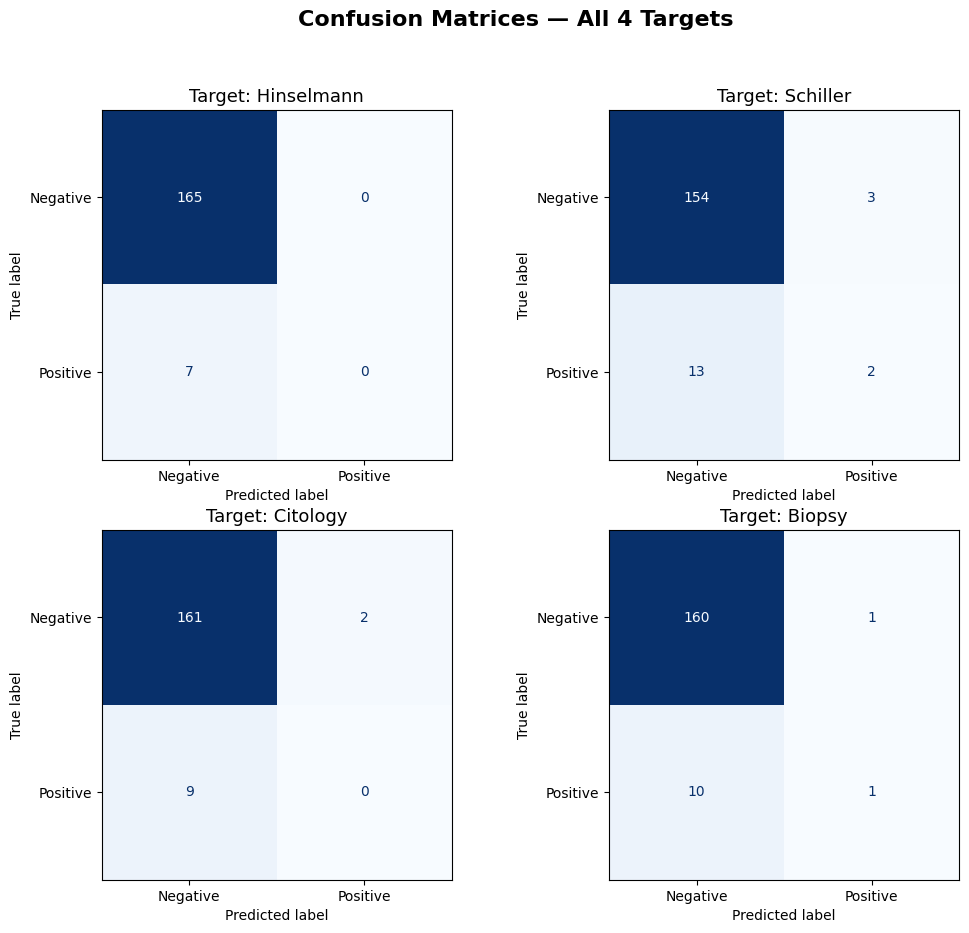

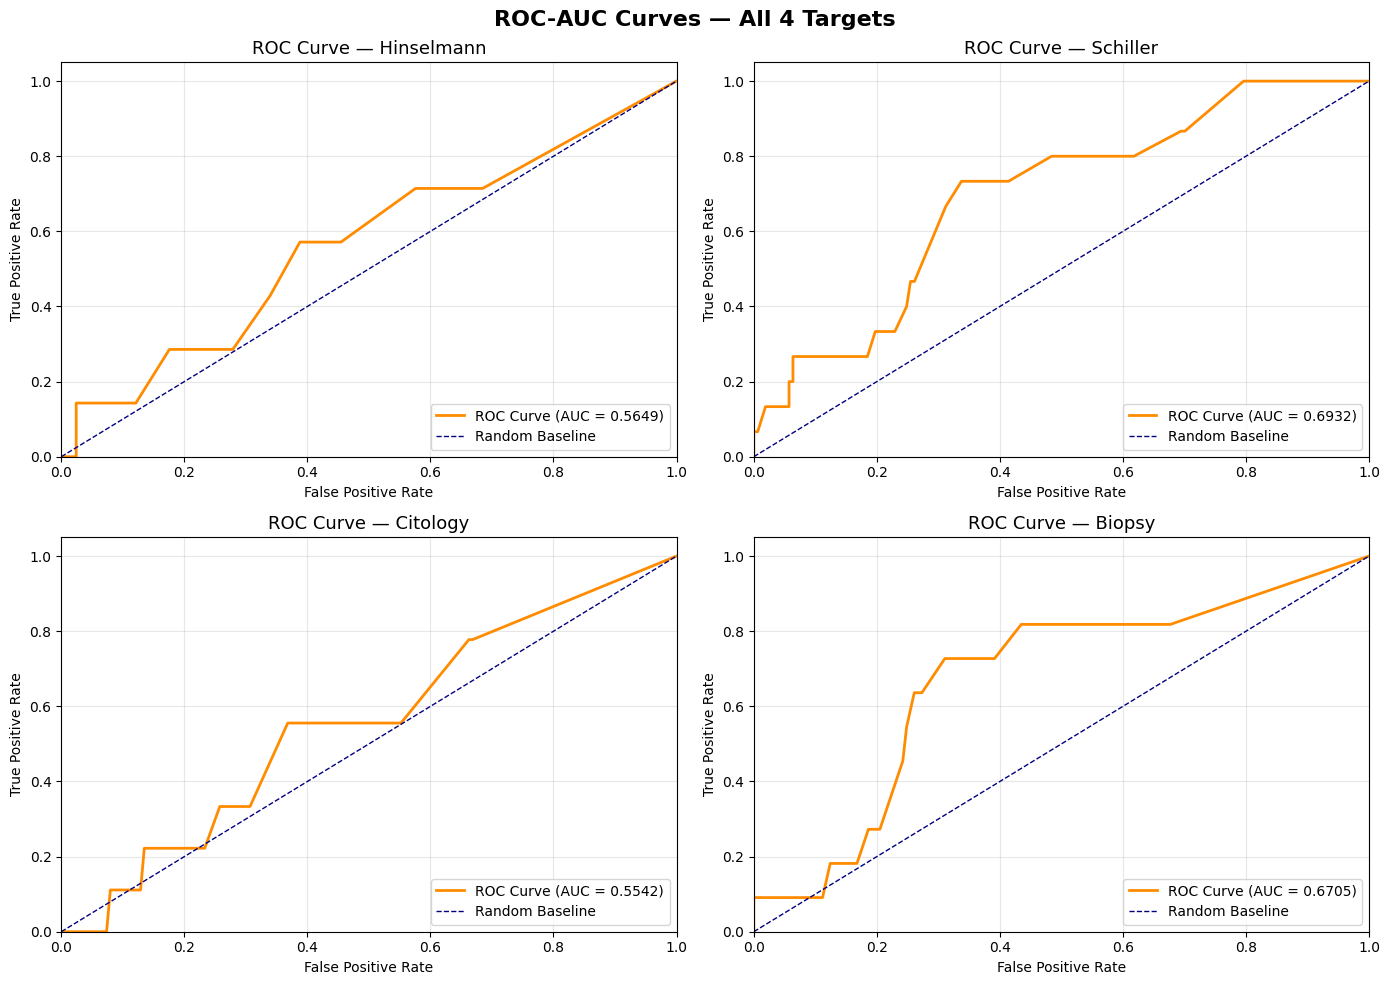


✅ ROC curves saved.


<Figure size 640x480 with 0 Axes>

✅ Confusion matrices saved.


In [14]:
# ============================================================
# PHASE 5: MODEL EVALUATION
# ============================================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

fig_roc, axes_roc = plt.subplots(2, 2, figsize=(14, 10))
fig_roc.suptitle("ROC-AUC Curves — All 4 Targets", fontsize=16, fontweight='bold')

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(12, 10))
fig_cm.suptitle("Confusion Matrices — All 4 Targets", fontsize=16, fontweight='bold')

for idx, target in enumerate(TARGETS):
    print(f"\n{'='*60}")
    print(f"EVALUATION — Target: {target}")
    print(f"{'='*60}")
    
    rf = models[target]
    X_train_s, X_test_s, y_train, y_test = splits[target]
    
    y_pred      = rf.predict(X_test_s)
    y_pred_prob = rf.predict_proba(X_test_s)[:, 1]
    
    # --- Classification Report ---
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred,zero_division=0, target_names=['Negative (0)', 'Positive (1)']))
    
    # --- ROC-AUC Score ---
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print(f"🎯 ROC-AUC Score: {roc_auc:.4f}")
    
    # --- Confusion Matrix (text) ---
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🔲 Confusion Matrix:\n{cm}")
    
    # --- Plot: Confusion Matrix ---
    ax_cm = axes_cm[idx // 2][idx % 2]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f"Target: {target}", fontsize=13)
    
    # --- Plot: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    ax_roc = axes_roc[idx // 2][idx % 2]
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Baseline')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curve — {target}', fontsize=13)
    ax_roc.legend(loc='lower right')
    ax_roc.grid(alpha=0.3)

plt.figure(fig_roc.number)
plt.tight_layout()
plt.savefig("roc_curves_all_targets.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ ROC curves saved.")

plt.figure(fig_cm.number)
plt.tight_layout()
plt.savefig("confusion_matrices_all_targets.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved.")